<a href="https://colab.research.google.com/github/amanilayouni/arene-des-algos--Amani_LAYOUNI-/blob/main/telco_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/amanilayouni/arene-des-algos--Amani_LAYOUNI-.git


Cloning into 'arene-des-algos--Amani_LAYOUNI-'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 44 (delta 15), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 60.18 KiB | 2.15 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [2]:
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(" Forme du dataset :", df.shape)

print("\n Types des colonnes :")
print(df.dtypes)

print("\n Aperçu des premières lignes :")
print(df.head())

print("\n Vérification valeurs manquantes :")
print(df.isna().sum().sort_values(ascending=False).head(10))



 Forme du dataset : (7043, 21)

 Types des colonnes :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

 Aperçu des premières lignes :
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2         

In [4]:
import pandas as pd

def audit_qualite(df):
    print("Forme :", df.shape)

    print("\nTypes des colonnes :")
    print(df.dtypes)

    missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_percent = missing_percent[missing_percent > 0]

    print("\nTaux de valeurs manquantes (%) par colonne :")
    if len(missing_percent) == 0:
        print("Aucune valeur manquante détectée")
    else:
        print(missing_percent.round(2))

    if "Churn" not in df.columns:
        print("\nColonne Churn absente")
        return

    churn_counts = df["Churn"].value_counts(dropna=False)
    total = len(df)

    print("\nRépartition de la cible Churn :")
    for label in churn_counts.index:
        count = churn_counts[label]
        percent = (count / total) * 100 if total > 0 else 0
        print(label, count, round(percent, 1))

In [5]:
audit_qualite(df)

Forme : (7043, 21)

Types des colonnes :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Taux de valeurs manquantes (%) par colonne :
Aucune valeur manquante détectée

Répartition de la cible Churn :
No 5174 73.5
Yes 1869 26.5


In [6]:
import numpy as np
import pandas as pd

def reparer_total_charges(df):
    df = df.copy()

    if "TotalCharges" not in df.columns:
        return df

    non_numeric_ratio = pd.to_numeric(df["TotalCharges"], errors="coerce").isna().mean()

    if non_numeric_ratio == 1:
        raise ValueError("TotalCharges est 100% non numérique")

    before_nan = pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

    df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    after_nan = df["TotalCharges"].isna().sum()
    new_nans = after_nan - (before_nan - df["TotalCharges"].isna().sum())

    median_value = df["TotalCharges"].median()
    df["TotalCharges"] = df["TotalCharges"].fillna(median_value)

    return df

In [8]:
df2 = reparer_total_charges(df)

print(df2["TotalCharges"].dtype)
print(df2["TotalCharges"].isna().sum())
print(df2.shape)
print(df2.head())

float64
0
(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies

In [9]:
import pandas as pd

def encoder_features(df):
    df = df.copy()

    if "customerID" in df.columns:
        df = df.drop(columns=["customerID"])

    bool_map = {"Yes": 1, "No": 0}

    for col in df.columns:
        if df[col].dtype == "object":
            unique_vals = df[col].dropna().unique()

            if set(unique_vals).issubset({"Yes", "No"}):
                df[col] = df[col].map(bool_map)
            else:
                df = pd.get_dummies(df, columns=[col], drop_first=False)

    return df

In [14]:
df_enc = encoder_features(df)

print("Shape :", df_enc.shape)

Shape : (7043, 6572)


In [15]:
print(df_enc.select_dtypes(include="object").columns)

Index([], dtype='object')


In [16]:
print("customerID présent :", "customerID" in df_enc.columns)

customerID présent : False


In [17]:
binary_cols = [col for col in df_enc.columns if set(df_enc[col].dropna().unique()).issubset({0, 1})]

print("Colonnes binaires :", binary_cols[:10])

Colonnes binaires : ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'gender_Female', 'gender_Male', 'MultipleLines_No', 'MultipleLines_No phone service']


In [18]:
print("Colonnes avant :", df.shape[1])
print("Colonnes après :", df_enc.shape[1])

Colonnes avant : 21
Colonnes après : 6572


In [19]:
print(df_enc.dtypes.value_counts())

bool       6564
int64         7
float64       1
Name: count, dtype: int64


In [20]:
print(df_enc.head())

   SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0              0        1           0       1             0                 1   
1              0        0           0      34             1                 0   
2              0        0           0       2             1                 1   
3              0        0           0      45             0                 0   
4              0        0           0       2             1                 1   

   MonthlyCharges  Churn  gender_Female  gender_Male  ...  \
0           29.85      0           True        False  ...   
1           56.95      0          False         True  ...   
2           53.85      1          False         True  ...   
3           42.30      0          False         True  ...   
4           70.70      1           True        False  ...   

   TotalCharges_995.35  TotalCharges_996.45  TotalCharges_996.85  \
0                False                False                False   
1         

In [25]:
import numpy as np

def detecter_outliers_iqr(df, colonne):
    q1 = df[colonne].quantile(0.25)
    q3 = df[colonne].quantile(0.75)
    iqr = q3 - q1

    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    outliers = df[(df[colonne] < borne_basse) | (df[colonne] > borne_haute)]

    return borne_basse, borne_haute, len(outliers)

=== DETECTION OUTLIERS IQR ===
tenure
borne basse: -60.0
borne haute: 124.0
outliers: 0
-----
MonthlyCharges
borne basse: -46.02499999999999
borne haute: 171.375
outliers: 0
-----
TotalCharges
borne basse: -4688.481250000001
borne haute: 8884.66875
outliers: 0
-----
=== BOXPLOTS ===


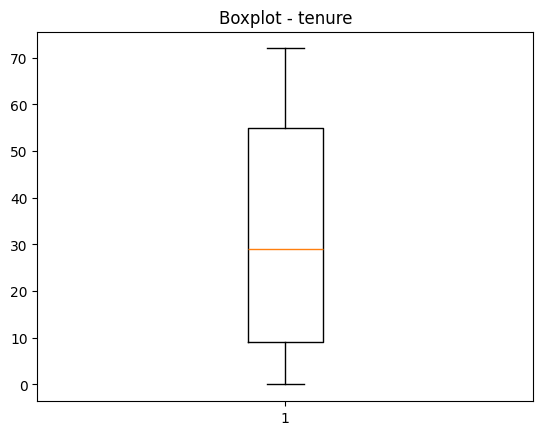

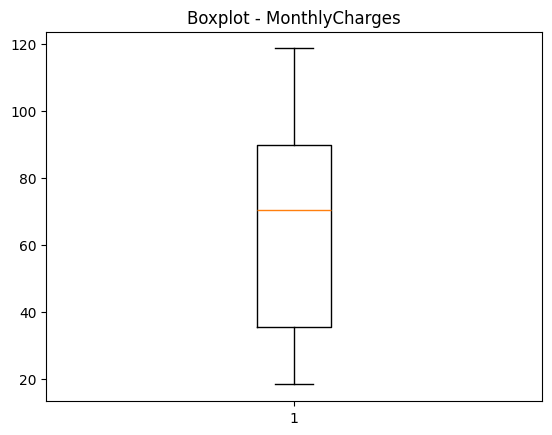

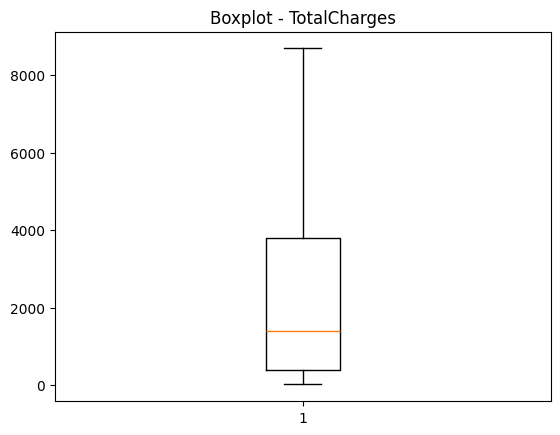

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def detecter_outliers_iqr(df, colonne):
    s = pd.to_numeric(df[colonne], errors="coerce")

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    outliers = s[(s < borne_basse) | (s > borne_haute)].count()

    return borne_basse, borne_haute, int(outliers)


def boxplots_iqr(df, colonnes):
    for c in colonnes:
        s = pd.to_numeric(df[c], errors="coerce")

        plt.figure()
        plt.boxplot(s.dropna())
        plt.title(f"Boxplot - {c}")
        plt.show()


def test_iqr(df):
    cols = ["tenure", "MonthlyCharges", "TotalCharges"]

    print("=== DETECTION OUTLIERS IQR ===")

    for c in cols:
        bmin, bmax, n = detecter_outliers_iqr(df, c)
        print(c)
        print("borne basse:", bmin)
        print("borne haute:", bmax)
        print("outliers:", n)
        print("-----")

    print("=== BOXPLOTS ===")
    boxplots_iqr(df, cols)


test_iqr(df)